In [ ]:
import cv2
from PIL import Image
import numpy as np
from torchvision.ops import box_convert
 
from groundingdino.models import build_model
from groundingdino.util.slconfig import SLConfig
from groundingdino.util.utils import clean_state_dict
from groundingdino.util.inference import annotate, load_image, predict
import groundingdino.datasets.transforms as T
 
from huggingface_hub import hf_hub_download

c:\Users\sirom\miniconda3\envs\grounding-dino-env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\sirom\miniconda3\envs\grounding-dino-env\lib\site-packages\timm\models\layers\__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [ ]:
import sys
sys.path.append("/absolute/path/to/GroundingDINO")

import groundingdino.datasets.transforms as T


<br><br>

In [2]:
import torch
print(torch.cuda.is_available()) # Output must be True

True


In [8]:
def load_model_hf(repo_id, filename, ckpt_config_filename, device='cuda'):
    cache_config_file = hf_hub_download(repo_id=repo_id, filename=ckpt_config_filename)
 
    args = SLConfig.fromfile(cache_config_file) 
    model = build_model(args)
    args.device = device
 
    cache_file = hf_hub_download(repo_id=repo_id, filename=filename)
    checkpoint = torch.load(cache_file, map_location='cuda')
    log = model.load_state_dict(clean_state_dict(checkpoint['model']), strict=False)
    print("Model loaded from {} \n => {}".format(cache_file, log))
    _ = model.eval()
    return model    
 
# Grounding DINO model
ckpt_repo_id = "ShilongLiu/GroundingDINO"
ckpt_filenmae = "groundingdino_swint_ogc.pth"
ckpt_config_filename = "GroundingDINO_SwinT_OGC.cfg.py"

In [9]:
model = load_model_hf(ckpt_repo_id, ckpt_filenmae, ckpt_config_filename)

final text_encoder_type: bert-base-uncased


Model loaded from C:\Users\sirom\.cache\huggingface\hub\models--ShilongLiu--GroundingDINO\snapshots\a94c9b567a2a374598f05c584e96798a170c56fb\groundingdino_swint_ogc.pth 
 => _IncompatibleKeys(missing_keys=[], unexpected_keys=['label_enc.weight', 'bert.embeddings.position_ids'])


In [18]:
# multiple text input
TEXT_PROMPT = "yacht."
BOX_TRESHOLD = 0.45
TEXT_TRESHOLD = 0.25
 
# path to the image
local_image_path = "boats.jpg"
# load the image
image_source, image = load_image(local_image_path)
 
# perform detection with text input on image
boxes, logits, phrases = predict(
    model=model, 
    image=image, 
    caption=TEXT_PROMPT, 
    box_threshold=BOX_TRESHOLD, 
    text_threshold=TEXT_TRESHOLD
)
 
# draw bboxes and label information
annotated_frame = annotate(image_source=image_source, boxes=boxes, logits=logits, phrases=phrases)
annotated_frame = annotated_frame[...,::-1] # BGR to RGB

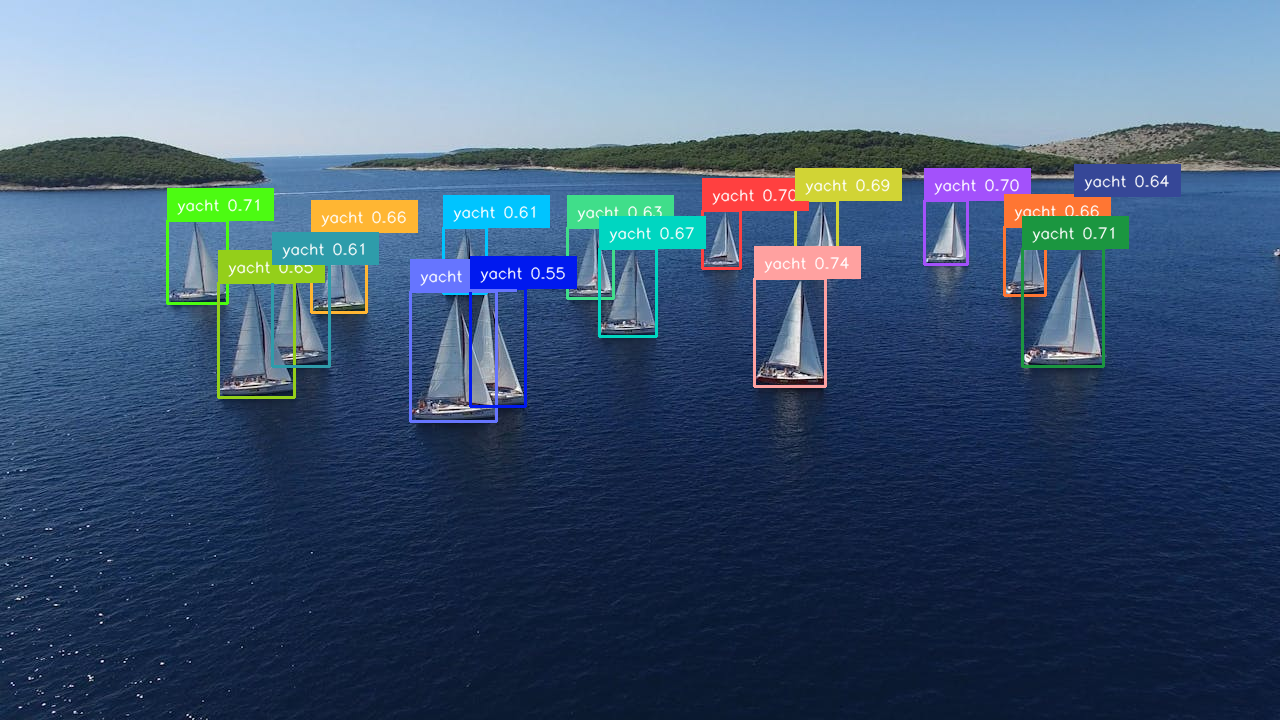

In [19]:
Image.fromarray(annotated_frame)